
# **Tutorial 8-A: Object Detection using Faster R-CNN (Custom Model)**

## **Objectives**

* Understand Faster R-CNN architecture.
* Understand Region of Interest (ROI) and Pooling.
* Learn about Intersection over Union (IoU).
* Calculate Mean Average Precision (mAP).

---

## **Step 1: Import Libraries**

We will begin by importing the necessary libraries for deep learning, image processing, and visualization.

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import cv2
import matplotlib.pyplot as plt
import random

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


---

## **Step 2: Construct the Backbone**

We will use a simple Convolutional Neural Network (CNN) as our feature extractor. This backbone will process the input image and produce a feature map.

In [2]:
# Define the Backbone Network (Simple CNN)
def build_backbone(input_shape=(224, 224, 3)):
    inputs = keras.Input(shape=input_shape)

    # Layer 1
    x = keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = keras.layers.MaxPooling2D((2, 2))(x)

    # Layer 2
    x = keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)

    # Layer 3
    x = keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)

    # Output Layer of Backbone
    outputs = keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same')(x)

    return keras.Model(inputs, outputs)

backbone = build_backbone()

### **Discussion: The Role of the Backbone**

The backbone serves as the "eyes" of the model. It transforms raw pixel data into a high-level feature map. As the image passes through deeper layers, the network identifies increasingly complex patterns, from simple edges to specific object parts.

---

## **Step 3: Constructing the Region Proposal Network (RPN)**

The RPN predicts regions of interest (ROIs) using anchors. It features two output layers:

* **Objectness score:** Predicts if an anchor contains an object.
* **Bounding box regression:** Adjusts anchor boxes to fit objects precisely.

In [3]:
# Build the Region Proposal Network (RPN)
def build_rpn(feature_map):
    # Shared convolutional layer for RPN
    rpn_conv = keras.layers.Conv2D(512, (3, 3), padding="same", activation="relu")(feature_map)

    # Classification: 9 anchors, 2 classes (object/non-object)
    rpn_class = keras.layers.Conv2D(18, (1, 1), activation="sigmoid")(rpn_conv)

    # Regression: 9 anchors, 4 bounding box values (x, y, w, h)
    rpn_bbox = keras.layers.Conv2D(36, (1, 1))(rpn_conv)

    return rpn_class, rpn_bbox

---

## **Step 4: Implement the ROI Pooling Layer**

The ROI Pooling Layer extracts fixed-size feature maps from the various ROIs proposed by the RPN, ensuring the downstream classification heads receive consistent input sizes.

In [4]:
class ROIPoolingLayer(tf.keras.layers.Layer):
    def __init__(self, pool_size, **kwargs):
        super(ROIPoolingLayer, self).__init__(**kwargs)
        self.pool_size = pool_size

    def call(self, inputs):
        feature_map, rois = inputs
        rois = tf.reshape(rois, (-1, 4))
        batch_indices = tf.zeros((tf.shape(rois)[0],), dtype=tf.int32)

        # Using crop_and_resize to simulate ROI pooling
        pooled_rois = tf.image.crop_and_resize(
            feature_map,
            boxes=rois,
            box_indices=batch_indices,
            crop_size=self.pool_size
        )
        return pooled_rois

    def compute_output_shape(self, input_shape):
        feature_map_shape, rois_shape = input_shape
        num_rois = rois_shape[0]
        return (num_rois, self.pool_size[0], self.pool_size[1], feature_map_shape[-1])

roi_pooling_layer = ROIPoolingLayer((7, 7))

---

## **Step 5: Create Classification and Regression Heads**

After pooling, we use dense layers to determine the specific class of the object and further refine the bounding box coordinates.

In [5]:
# Create Classification and Regression Heads
def build_heads(pooled_rois, num_classes):
    flatten = keras.layers.Flatten()(pooled_rois)
    dense = keras.layers.Dense(1024, activation="relu")(flatten)

    # Final classification (Softmax)
    classifier = keras.layers.Dense(num_classes, activation="softmax")(dense)

    # Final bounding box regression (4 values per box)
    bbox_regressor = keras.layers.Dense(num_classes * 4)(dense)

    return classifier, bbox_regressor

---

## **Step 6: Assembling the Complete Faster R-CNN Model**

We now bring all the previous components together into a single functional model.

In [6]:
def build_faster_rcnn(num_classes, input_shape=(224, 224, 3)):
    input_image = keras.Input(shape=input_shape)
    input_rois = keras.Input(shape=(None, 4)) # ROIs Input

    # 1. Backbone (Feature extraction)
    backbone_model = build_backbone(input_shape)
    feature_map = backbone_model(input_image)

    # 2. RPN
    rpn_class, rpn_bbox = build_rpn(feature_map)

    # 3. ROI Pooling
    pooled_rois = roi_pooling_layer([feature_map, input_rois])

    # 4. Classification & Regression heads
    classifier, bbox_regressor = build_heads(pooled_rois, num_classes)

    # Build complete model
    model = keras.Model(inputs=[input_image, input_rois],
                        outputs=[rpn_class, rpn_bbox, classifier, bbox_regressor])
    return model

# Instantiate and summarize
num_classes = 80 # Example for COCO dataset
faster_rcnn = build_faster_rcnn(num_classes)
faster_rcnn.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_1        │ (None, 28, 28,    │  1,550,976 │ input_layer_1[0]… │
│ (Functional)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, None, 4)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ roi_pooling_layer   │ (None, 7, 7, 512) │          0 │ functional_1[0][… │
│ (ROIPoolingLayer)   │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 25088)     │          0 │ roi_pooling_laye… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 28, 28,    │  2,359,808 │ functional_1[0][… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1024)      │ 25,691,136 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 28, 28,    │      9,234 │ conv2d_8[0][0]    │
│                     │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 28, 28,    │     18,468 │ conv2d_8[0][0]    │
│                     │ 36)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 80)        │     82,000 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 320)       │    328,000 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 30,039,622 (114.59 MB)

 Trainable params: 30,039,622 (114.59 MB)

 Non-trainable params: 0 (0.00 B)

---

## **Step 7: Calculating Intersection over Union (IoU)**

IoU measures the overlap between the predicted bounding box and the ground truth box.

In [7]:
def calculate_iou(box1, box2):
    ymin1, xmin1, ymax1, xmax1 = box1
    ymin2, xmin2, ymax2, xmax2 = box2

    # Determine intersection coordinates
    inter_xmin = max(xmin1, xmin2)
    inter_ymin = max(ymin1, ymin2)
    inter_xmax = min(xmax1, xmax2)
    inter_ymax = min(ymax1, ymax2)

    # Calculate area of intersection
    inter_area = max(0, inter_xmax - inter_xmin) * max(0, inter_ymax - inter_ymin)

    # Calculate area of both boxes
    area1 = (xmax1 - xmin1) * (ymax1 - ymin1)
    area2 = (xmax2 - xmin2) * (ymax2 - ymin2)

    # Calculate Union
    union_area = area1 + area2 - inter_area

    return inter_area / union_area if union_area != 0 else 0

---

## **Step 8: Calculating Precision & Recall**

These metrics help evaluate how many detections were correct (Precision) and how many actual objects were found (Recall).

In [8]:
def calculate_precision_recall(pred_boxes, pred_scores, pred_labels, gt_boxes, gt_labels, iou_threshold=0.5):
    tp, fp = 0, 0
    matched_gt = set()

    for i, pred_box in enumerate(pred_boxes):
        best_iou = 0
        best_gt_index = -1

        for j, gt_box in enumerate(gt_boxes):
            if pred_labels[i] == gt_labels[j] and j not in matched_gt:
                iou = calculate_iou(pred_box, gt_box)
                if iou > best_iou:
                    best_iou = iou
                    best_gt_index = j

        if best_iou > iou_threshold:
            tp += 1
            matched_gt.add(best_gt_index)
        else:
            fp += 1

    fn = len(gt_boxes) - len(matched_gt)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    return precision, recall

---

## **Step 9: Calculating Average Precision (AP) and mAP**

Average Precision is the area under the Precision-Recall curve. Mean Average Precision (mAP) is the average AP across all object classes.

In [9]:
def calculate_ap(precisions, recalls):
    # Append sentinel values
    precisions = [0.0] + precisions + [0.0]
    recalls = [0.0] + recalls + [1.0]

    # Ensure precision is non-increasing
    for i in range(len(precisions) - 1, 0, -1):
        precisions[i-1] = max(precisions[i-1], precisions[i])

    # Calculate area under curve
    indices = [i for i in range(1, len(recalls)) if recalls[i] != recalls[i-1]]
    ap = sum((recalls[i] - recalls[i-1]) * precisions[i] for i in indices)
    return ap

def calculate_map(predictions, ground_truths, num_classes, iou_threshold=0.5):
    average_precisions = []

    for class_id in range(1, num_classes):
        all_precisions = []
        all_recalls = []

        for pred, gt in zip(predictions, ground_truths):
            # Filter by class
            p_boxes = [box for i, box in enumerate(pred["boxes"]) if pred["labels"][i] == class_id]
            p_scores = [score for i, score in enumerate(pred["scores"]) if pred["labels"][i] == class_id]
            g_boxes = [box for i, box in enumerate(gt["boxes"]) if gt["labels"][i] == class_id]
            g_labels = [class_id] * len(g_boxes)
            p_labels = [class_id] * len(p_boxes)

            precision, recall = calculate_precision_recall(p_boxes, p_scores, p_labels, g_boxes, g_labels, iou_threshold)
            all_precisions.append(precision)
            all_recalls.append(recall)

        ap = calculate_ap(all_precisions, all_recalls)
        average_precisions.append(ap)

    return np.mean(average_precisions)

---

## **Step 10: Testing with Sample Values**

We will now test our mAP calculation logic using placeholder data.

In [10]:
# Placeholder predictions and ground truths for testing
predictions = [
    {'boxes': [[0.1, 0.1, 0.4, 0.4], [0.5, 0.5, 0.8, 0.8]], 'scores': [0.9, 0.7], 'labels': [1, 2]}
]

ground_truths = [
    {'boxes': [[0.12, 0.12, 0.42, 0.42], [0.5, 0.5, 0.8, 0.8]], 'labels': [1, 2]}
]

num_classes = 3 # Background, Class 1, Class 2
mean_ap = calculate_map(predictions, ground_truths, num_classes)
print(f"Mean Average Precision (mAP): {mean_ap:.2f}")

Mean Average Precision (mAP): 1.00


### **Discussion: Numerical Area Calculation**

Average Precision is approximated using rectangular integration. As shown in the tutorial examples:

* $AP = \sum(R_n - R_{n-1}) \times P_n$
* In the provided example table where recall increments from $0.1$ to $1.0$, the summed area resulted in an $AP = 0.81$.


# Task 1: Change the Number of Layers
In deep learning, changing the "depth" of the backbone affects how features are extracted. Increasing layers can capture more complex features but requires more computational power.
## Modified Backbone (Deeper CNN)
We will add an extra Convolutional block and a Dropout layer to prevent overfitting.

In [11]:
def build_deeper_backbone(input_shape=(224, 224, 3)):
    inputs = keras.Input(shape=input_shape)

    # Block 1
    x = keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = keras.layers.MaxPooling2D((2, 2))(x)

    # Block 2
    x = keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)

    # Block 3 (New added layer)
    x = keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)

    # Block 4
    x = keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same')(x)
    x = keras.layers.Dropout(0.2)(x) # Added for regularization

    return keras.Model(inputs, x)

# Re-build the model with the deeper backbone
deeper_backbone = build_deeper_backbone()
deeper_backbone.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 512)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,141,056 (8.17 MB)

 Trainable params: 2,141,056 (8.17 MB)

 Non-trainable params: 0 (0.00 B)

# Task 2: Random Data Testing
This step allows us to verify that the model's dimensions and output shapes are correct before we start the long process of training.

In [12]:
# Create a dummy image (Random noise)
random_image = np.random.rand(1, 224, 224, 3).astype(np.float32)

# Create a dummy ROI (y1, x1, y2, x2) normalized between 0 and 1
random_rois = np.array([[[0.1, 0.1, 0.5, 0.5]]], dtype=np.float32)

# Run a prediction through the model
# Note: faster_rcnn is the model we assembled in Step 6
predictions = faster_rcnn.predict([random_image, random_rois])

print("RPN Class Shape:", predictions[0].shape)
print("Classifier Output (Softmax):", predictions[2])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step
RPN Class Shape: (1, 28, 28, 18)
Classifier Output (Softmax): [[0.01198962 0.01214611 0.01191959 0.01324008 0.0122257  0.0132427
  0.01323075 0.01258651 0.01197249 0.01189937 0.0123074  0.01147565
  0.01238479 0.01253669 0.01163434 0.01396215 0.01202887 0.0119041
  0.01336797 0.01251074 0.01361268 0.01294477 0.01300345 0.01142365
  0.01170498 0.01286871 0.01090537 0.01316895 0.01197292 0.01275835
  0.01136946 0.01238494 0.01403727 0.01166355 0.01240388 0.01329133
  0.0139407  0.01172235 0.01328389 0.01234012 0.01261298 0.01187298
  0.01339934 0.01171638 0.01189889 0.01214754 0.01202564 0.0121109
  0.01114026 0.01311646 0.01226316 0.01268371 0.01304227 0.0122167
  0.01371306 0.01243766 0.01234023 0.01220271 0.01260462 0.01153702
  0.01286042 0.0119984  0.01241288 0.01290194 0.01245733 0.01320305
  0.01273676 0.01165916 0.0123927  0.01224483 0.01285921 0.01265718
  0.01187512 0.01219709 0.0122758  0.01340835 0.01202571 0.01393668
  0.01245858 0.0149

# **TASK 3: DATA LABELLING**

DATASET IS AERIAL MERITIME DETECTION-TRAIN FILE AND DATALABELLING IS DONE USING ROBOFLOW OBJECT DETECTION MODEL .GIVEN BELOW IS RESULTS SCREENSHOTS FR MY CUSOMIZED DATA
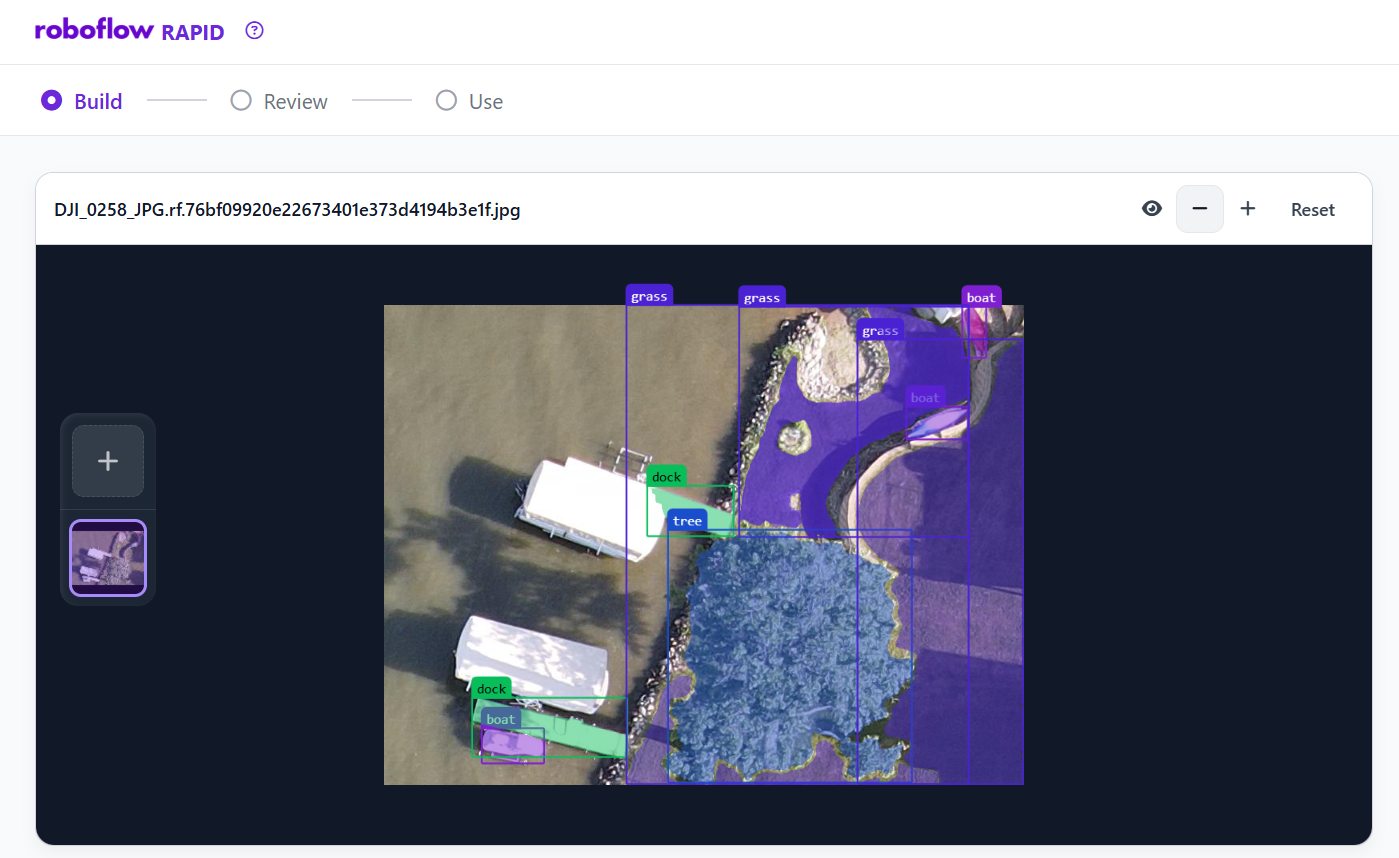